# Energy network dispatch and reporting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/energy_networks/01_energy_dispatch_and_reporting.ipynb)

This notebook demonstrates deterministic multi-source and multi-load allocation, priority-based shortage handling, balancing resources, cost, emissions, and auditable reports.

**Release requirement:** NeqSim 3.17.0 or later.\n\n**Implementation history:** Energy Networks v3 and PR #2613 for optional minimum-cost/minimum-emissions strategies.

```text
Wind ─┐
Grid ─┼─> Electrical EnergyBus ─> Critical load
GT   ─┘                         └> Flexible load
```
**Validated environment:** stored outputs use NeqSim 3.17.0, Python 3.12.13, and OpenJDK 17.0.19.


## 1. Setup

In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys

if (
    importlib.util.find_spec("google") is not None
    and importlib.util.find_spec("google.colab") is not None
):
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim==3.17.0",
        ],
        check=True,
    )

from neqsim import jneqsim
from jpype import JClass

neqsim_version = importlib.metadata.version("neqsim")
if neqsim_version != "3.17.0":
    raise RuntimeError(
        "This stored-output example was validated with NeqSim 3.17.0; " f"found {neqsim_version}."
    )
print(f"NeqSim {neqsim_version} loaded from the public Python package")


NeqSim 3.17.0 loaded from the public Python package


In [2]:
EnergyBus = jneqsim.process.equipment.stream.EnergyBus
EnergyPort = jneqsim.process.equipment.stream.EnergyPort
EnergyType = jneqsim.process.equipment.stream.EnergyType
EnergyPortDirection = jneqsim.process.equipment.stream.EnergyPortDirection
EnergyPortMode = jneqsim.process.equipment.stream.EnergyPortMode
EnergyDispatchStrategy = jneqsim.process.equipment.stream.EnergyDispatchStrategy


## 2. Build a multi-source electrical network

In [3]:
bus = EnergyBus("platform electrical bus", EnergyType.ELECTRICAL)


def port(owner, direction, mode):
    p = EnergyPort("power", EnergyType.ELECTRICAL, direction, mode)
    p.setOwnerName(owner)
    p.connect(bus)
    return p


wind = port("wind", EnergyPortDirection.OUTPUT, EnergyPortMode.CALCULATED)
gas_turbine = port("gas turbine", EnergyPortDirection.OUTPUT, EnergyPortMode.CALCULATED)
grid = port("grid import", EnergyPortDirection.OUTPUT, EnergyPortMode.SPECIFICATION)
critical = port("critical process load", EnergyPortDirection.INPUT, EnergyPortMode.SPECIFICATION)
flexible = port("flexible process load", EnergyPortDirection.INPUT, EnergyPortMode.SPECIFICATION)

wind.setDuty(8.0, "MW")
gas_turbine.setDuty(10.0, "MW")
grid.setRequestedPower(6.0, "MW")
critical.setRequestedPower(12.0, "MW")
flexible.setRequestedPower(8.0, "MW")

critical.setPriority(10)
flexible.setPriority(20)

wind.setEnergyPricePerMWh(0.0)
wind.setEmissionFactorKgPerMWh(0.0)
gas_turbine.setEnergyPricePerMWh(90.0)
gas_turbine.setEmissionFactorKgPerMWh(450.0)
grid.setEnergyPricePerMWh(120.0)
grid.setEmissionFactorKgPerMWh(250.0)

report = bus.solveBalance()
print(report.toJson())


{
  "busName": "platform electrical bus",
  "allocations": [
    {
      "participantId": "2e28b2a6-294c-4caf-8af9-20cc78411525",
      "participantName": "wind.power",
      "mode": "CALCULATED",
      "direction": "OUTPUT",
      "priority": 100,
      "requestedPower": 8000000.0,
      "allocatedPower": 6666666.666666667,
      "unmetPower": 0.0,
      "curtailedPower": 1333333.333333333
    },
    {
      "participantId": "967245e0-da34-4d92-8e63-9789a9ce1342",
      "participantName": "gas turbine.power",
      "mode": "CALCULATED",
      "direction": "OUTPUT",
      "priority": 100,
      "requestedPower": 1.0E7,
      "allocatedPower": 8333333.333333333,
      "unmetPower": 0.0,
      "curtailedPower": 1666666.666666667
    },
    {
      "participantId": "207a342f-0aa6-47b3-90a0-0f7e1dfd03a4",
      "participantName": "grid import.power",
      "mode": "SPECIFICATION",
      "direction": "OUTPUT",
      "priority": 100,
      "requestedPower": 6000000.0,
      "allocatedPower":

## 3. Extract allocations

In [4]:
import pandas as pd

rows = []
for item in report.getAllocations():
    rows.append(
        {
            "participant": str(item.getParticipantName()),
            "requested_MW": item.getRequestedPower() / 1e6,
            "allocated_MW": item.getAllocatedPower() / 1e6,
            "unmet_MW": item.getUnmetPower() / 1e6,
            "curtailed_MW": item.getCurtailedPower() / 1e6,
        }
    )
allocations = pd.DataFrame(rows)
allocations


Out[4]: 
                   participant  requested_MW  ...  unmet_MW  curtailed_MW
0                   wind.power           8.0  ...       0.0      1.333333
1            gas turbine.power          10.0  ...       0.0      1.666667
2            grid import.power           6.0  ...       0.0      1.000000
3  critical process load.power          12.0  ...       0.0      0.000000
4  flexible process load.power           8.0  ...       0.0      0.000000

[5 rows x 5 columns]


## 4. Visualize dispatch

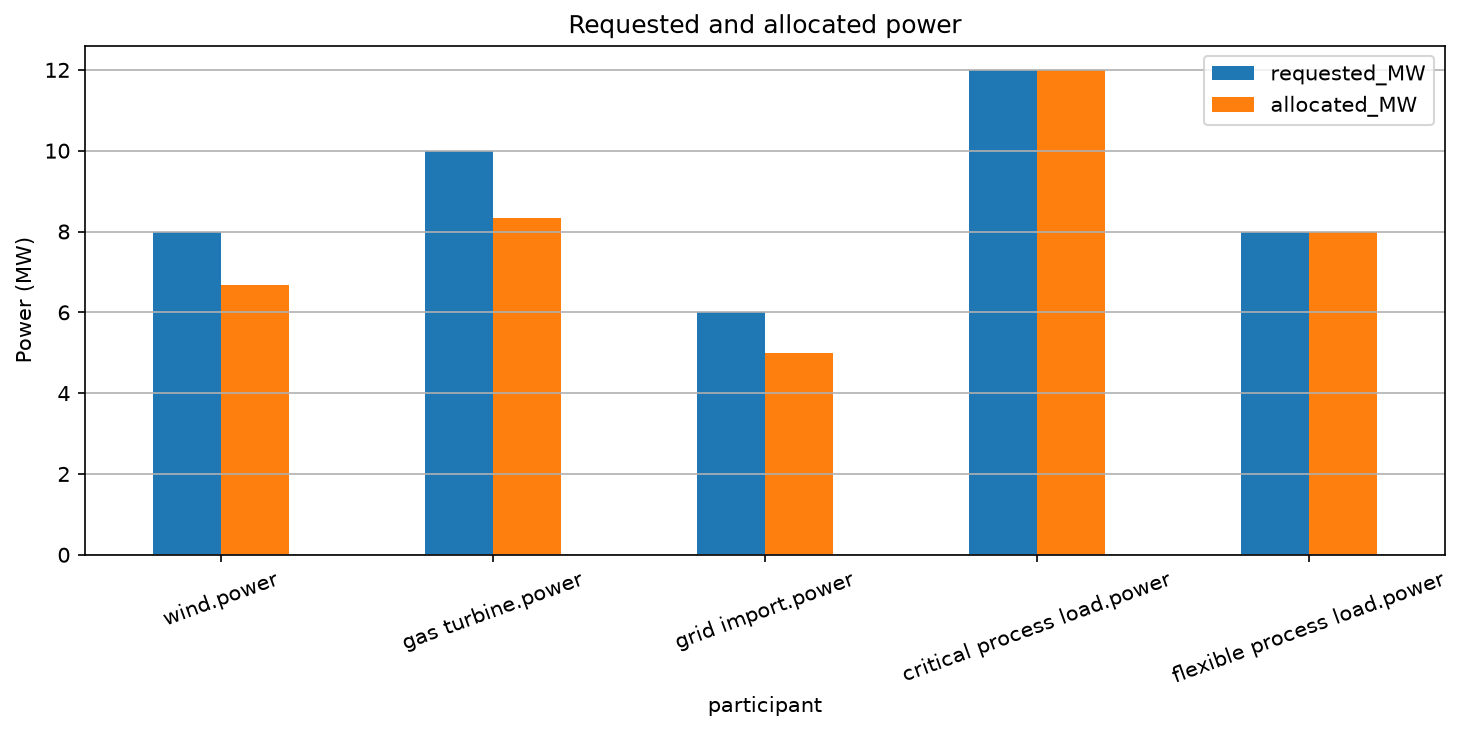

In [5]:
import matplotlib.pyplot as plt

ax = allocations.set_index("participant")[["requested_MW", "allocated_MW"]].plot(
    kind="bar",
    figsize=(10, 5),
)
ax.set_ylabel("Power (MW)")
ax.set_title("Requested and allocated power")
ax.tick_params(axis="x", labelrotation=20)
ax.grid(axis="y")
plt.tight_layout()
plt.show()


**Interpretation.** Critical loads are served before flexible loads. The gap between request and allocation identifies curtailment or unmet demand at participant level.

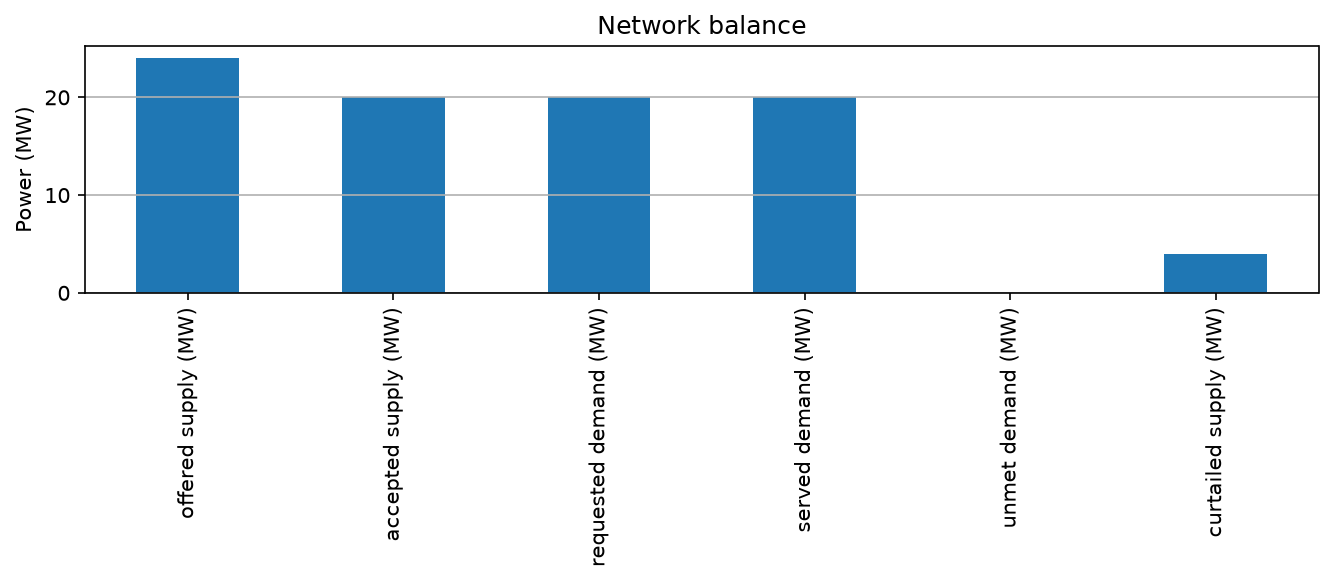

In [6]:
summary = pd.Series(
    {
        "offered supply (MW)": report.getOfferedSupply() / 1e6,
        "accepted supply (MW)": report.getAcceptedSupply() / 1e6,
        "requested demand (MW)": report.getRequestedDemand() / 1e6,
        "served demand (MW)": report.getServedDemand() / 1e6,
        "unmet demand (MW)": report.getUnmetDemand() / 1e6,
        "curtailed supply (MW)": report.getCurtailedSupply() / 1e6,
    }
)
ax = summary.plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("Power (MW)")
ax.set_title("Network balance")
ax.grid(axis="y")
plt.tight_layout()
plt.show()


**Interpretation.** Network-level KPIs distinguish shortage from curtailment. This is the primary operational view for capacity and reserve screening.

## 5. Compare dispatch strategies

In [7]:
strategies = []
if EnergyDispatchStrategy is not None:
    for name in ["PRIORITY_PROPORTIONAL", "MINIMUM_COST", "MINIMUM_EMISSIONS"]:
        bus.setDispatchStrategy(getattr(EnergyDispatchStrategy, name))
        r = bus.solveBalance()
        strategies.append(
            {
                "strategy": name,
                "cost_per_h": r.getOperatingCostPerHour(),
                "co2_kg_per_h": r.getCo2EmissionRate(),
                "served_MW": r.getServedDemand() / 1e6,
            }
        )
else:
    strategies.append(
        {
            "strategy": "PRIORITY_PROPORTIONAL",
            "cost_per_h": report.getOperatingCostPerHour(),
            "co2_kg_per_h": report.getCo2EmissionRate(),
            "served_MW": report.getServedDemand() / 1e6,
        }
    )
strategy_df = pd.DataFrame(strategies)
strategy_df


Out[7]: 
                strategy  cost_per_h  co2_kg_per_h  served_MW
0  PRIORITY_PROPORTIONAL      1350.0        5000.0       20.0
1           MINIMUM_COST      1140.0        5000.0       20.0
2      MINIMUM_EMISSIONS      1260.0        4200.0       20.0


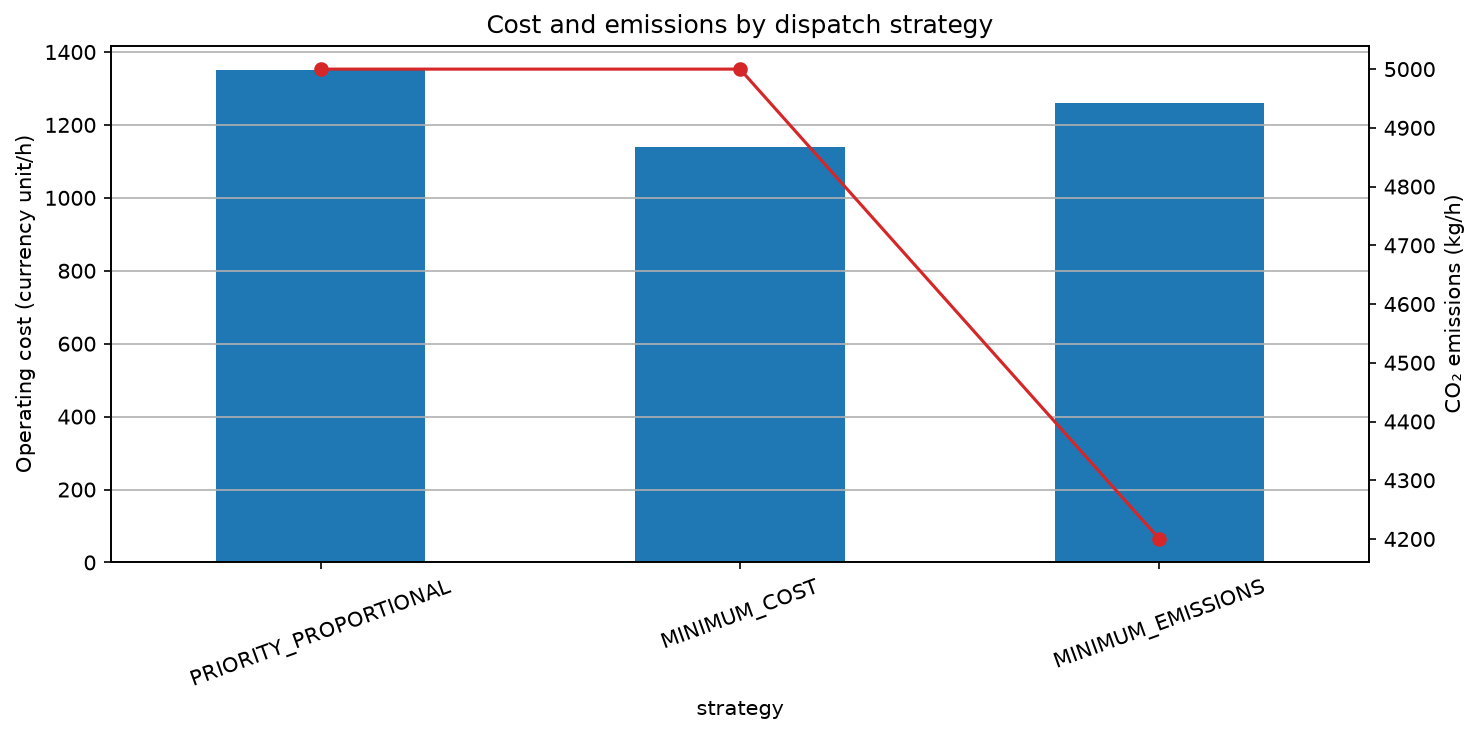

In [8]:
ax = strategy_df.plot(
    x="strategy",
    y="cost_per_h",
    kind="bar",
    color="tab:blue",
    figsize=(10, 5),
    legend=False,
)
strategy_df.plot(
    x="strategy",
    y="co2_kg_per_h",
    color="tab:red",
    marker="o",
    secondary_y=True,
    ax=ax,
    legend=False,
)
ax.set_ylabel("Operating cost (currency unit/h)")
ax.right_ax.set_ylabel("CO₂ emissions (kg/h)")
ax.set_title("Cost and emissions by dispatch strategy")
ax.tick_params(axis="x", labelrotation=20)
ax.grid(axis="y")
plt.tight_layout()
plt.show()


**Interpretation.** Minimum-cost and minimum-emissions dispatch can select different source combinations. The priority/proportional policy remains the transparent default.

## Validation checks

The assertions below lock the engineering balances and benchmark values used in the interpretation.


In [9]:
assert abs(report.getServedDemand() / 1e6 - 20.0) < 1e-9
assert abs(report.getUnmetDemand()) < 1e-9
assert abs(report.getCurtailedSupply() / 1e6 - 4.0) < 1e-9
assert strategy_df["served_MW"].eq(20.0).all()
assert strategy_df["cost_per_h"].min() <= report.getOperatingCostPerHour()
assert strategy_df["co2_kg_per_h"].min() <= report.getCo2EmissionRate()

validation = pd.Series(
    {
        "power balance residual (W)": report.getAcceptedSupply() - report.getServedDemand(),
        "served demand (MW)": report.getServedDemand() / 1e6,
        "unmet demand (MW)": report.getUnmetDemand() / 1e6,
        "curtailed supply (MW)": report.getCurtailedSupply() / 1e6,
    }
)
validation


Out[9]: 
power balance residual (W)     0.0
served demand (MW)            20.0
unmet demand (MW)              0.0
curtailed supply (MW)          4.0
dtype: float64


## Summary

This notebook demonstrated:

- deterministic multi-party allocation;
- critical versus flexible demand priorities;
- shortage and curtailment reporting;
- cost and CO₂ accounting;
- optional merit-order dispatch.

For detailed electrical load flow, protection, and fault studies, couple NeqSim to a specialist power-system solver.